# Test 05: Верификация теории

**Цель:** Формализация и проверка теоретических утверждений, появившихся в ходе экспериментов 01-04. Закрытие theoretical gap между `proofs.md` и notebook-доказательствами.

**Верифицируемые утверждения:**

1. **Теорема 1** (повторная символьная и численная проверка): $|f(x)| \leq 1 + w$ и $|f'(x)| \leq a + wb$
2. **Предложение 3** (новое): для $g(z) = z + \alpha\,\mathrm{chaos}(Wz + b)$ и $\alpha = 1/T$ верно $\|z_T\|_\infty \leq 2(1+w)$
3. **Свойство 4** (предварительное): связь формы латентного распределения и пригодности к квантизации
4. **Теорема 5** (кандидат): устранение мёртвых экспертов в chaos-MoE — условно на N=3 V2 в эксперименте 04

**План:**

1. Символьная проверка Теоремы 1 через `sympy` + численная сверка
2. Полная формулировка Предложения 3 с доказательством
3. Monte-Carlo верификация Предложения 3 на T ∈ {2, 4, 8, 16, 32}, N=20000 траекторий
4. Эмпирические данные для Свойства 4 из эксперимента 02 (entropy + kurtosis)
5. Формулировка Теоремы 5 как кандидата
6. Сохранение результатов в `jsons/theory_verification_*.json`

**Время прогона:** ~3-5 минут (Monte-Carlo + sympy, нет тренировки).

In [1]:
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

PROTO_DIR = Path('.').resolve()
JSONS_DIR = PROTO_DIR.parent / 'jsons'

## 1. Теорема 1: символьная и численная верификация

$f(x) = \sin(ax) + w \tanh(bx)$

- (i) **Ограниченность:** $|f(x)| \leq 1 + w$
- (iii) **Константа Липшица:** $|f'(x)| \leq a + wb$, супремум при $x=0$

### Доказательство

$|\sin(ax)| \leq 1$ и $|w\tanh(bx)| \leq w$ покомпонентно $\Rightarrow |f| \leq 1 + w$.

$f'(x) = a\cos(ax) + wb\,\mathrm{sech}^2(bx)$. В точке $x=0$: $f'(0) = a + wb$, и $\cos$, $\mathrm{sech}^2$ достигают единицы только в нуле. □

In [2]:
# === Символьная проверка через sympy ===

x, a, w, b = sp.symbols('x a w b', real=True, positive=True)
f = sp.sin(a*x) + w * sp.tanh(b*x)
f_prime = sp.diff(f, x)
f_prime_at_0 = f_prime.subs(x, 0)

# === Численная сверка для (a, w, b) = (1, 0.5, 4) ===

a_val, w_val, b_val = 1.0, 0.5, 4.0
L_theor = a_val + w_val * b_val
xs = np.linspace(-10, 10, 10000)
f_vals = np.sin(a_val * xs) + w_val * np.tanh(b_val * xs)
f_prime_vals = a_val * np.cos(a_val * xs) + w_val * b_val * (1 - np.tanh(b_val * xs)**2)

thm1 = {
    'symbolic_f': str(f),
    'symbolic_f_prime': str(f_prime),
    'symbolic_f_prime_at_0': str(f_prime_at_0),
    'measured_f_max': float(np.abs(f_vals).max()),
    'theoretical_f_bound': 1 + w_val,
    'measured_fprime_max': float(np.abs(f_prime_vals).max()),
    'theoretical_lipschitz': L_theor,
    'pass_boundedness': bool(np.abs(f_vals).max() <= 1 + w_val + 1e-6),
    'pass_lipschitz': bool(np.abs(f_prime_vals).max() <= L_theor + 1e-6),
}
thm1

{'symbolic_f': 'w*tanh(b*x) + sin(a*x)',
 'symbolic_f_prime': 'a*cos(a*x) + b*w*(1 - tanh(b*x)**2)',
 'symbolic_f_prime_at_0': 'a + b*w',
 'measured_f_max': 1.4999999807419018,
 'theoretical_f_bound': 1.5,
 'measured_fprime_max': 2.999967493840533,
 'theoretical_lipschitz': 3.0,
 'pass_boundedness': True,
 'pass_lipschitz': True}

## 2. Предложение 3: ограниченность рекурсии (новая теорема)

Пусть $g(z) = z + \alpha \cdot \mathrm{chaos}(Wz + b)$ с $|\mathrm{chaos}(\cdot)|_\infty \leq 1+w$ (Теорема 1(i)).

Для $z_{t+1} = g(z_t)$ при $\|z_0\|_\infty \leq 1+w$:

$$\|z_T\|_\infty \leq (1+w)(1 + T\alpha)$$

При $\alpha = 1/T$: $\|z_T\|_\infty \leq 2(1+w)$.

### Доказательство

$$z_T = z_0 + \alpha \sum_{t=0}^{T-1} \mathrm{chaos}(W z_t + b)$$

По неравенству треугольника покомпонентно:
$$\|z_T\|_\infty \leq \|z_0\|_\infty + \alpha \sum_{t=0}^{T-1} \|\mathrm{chaos}(\cdot)\|_\infty \leq (1+w) + \alpha T(1+w) = (1+w)(1 + T\alpha)$$

При $\alpha = 1/T$ граница равна $2(1+w)$. □

**Точность границы:** достигается, если все $\mathrm{chaos}(W z_t + b)$ имеют одинаковый знак на траектории. Эмпирически проверено в эксперименте 02 (range = [-3.00, 3.00] до 3-го знака для $w=0.5$, $T \in \{4, 8\}$).

In [3]:
# === Monte-Carlo верификация: 20000 траекторий, T ∈ {2, 4, 8, 16, 32} ===

def chaos_np(y, a=1.0, w=0.5, b=4.0):
    return np.sin(a * y) + w * np.tanh(b * y)


def simulate(T, alpha, n_traj=20000, dim=64, w=0.5, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((n_traj, dim, dim)) / np.sqrt(dim)
    bias = rng.standard_normal((n_traj, dim))
    z = rng.uniform(-(1 + w), (1 + w), size=(n_traj, dim))
    for _ in range(T):
        z = z + alpha * chaos_np(np.einsum('nij,nj->ni', W, z) + bias)
    return float(np.abs(z).max())


T_sweep = [2, 4, 8, 16, 32]
modes = [(1.0, 'naive'), (None, 'scaled')]
results_p3 = []
for T in T_sweep:
    for alpha_const, mode in modes:
        alpha = alpha_const if alpha_const is not None else 1.0 / T
        meas = simulate(T, alpha)
        bound = (1 + 0.5) * (1 + T * alpha)
        results_p3.append({'T': T, 'alpha': alpha, 'mode': mode,
                            'measured': meas, 'bound': bound,
                            'pass': meas <= bound + 0.01})

results_p3

[{'T': 2,
  'alpha': 1.0,
  'mode': 'naive',
  'measured': 4.497742604598719,
  'bound': 4.5,
  'pass': True},
 {'T': 2,
  'alpha': 0.5,
  'mode': 'scaled',
  'measured': 2.9993031883579526,
  'bound': 3.0,
  'pass': True},
 {'T': 4,
  'alpha': 1.0,
  'mode': 'naive',
  'measured': 7.475482056925902,
  'bound': 7.5,
  'pass': True},
 {'T': 4,
  'alpha': 0.25,
  'mode': 'scaled',
  'measured': 2.9972990421501255,
  'bound': 3.0,
  'pass': True},
 {'T': 8,
  'alpha': 1.0,
  'mode': 'naive',
  'measured': 13.356950628663373,
  'bound': 13.5,
  'pass': True},
 {'T': 8,
  'alpha': 0.125,
  'mode': 'scaled',
  'measured': 2.997429497969051,
  'bound': 3.0,
  'pass': True},
 {'T': 16,
  'alpha': 1.0,
  'mode': 'naive',
  'measured': 24.974681140110015,
  'bound': 25.5,
  'pass': True},
 {'T': 16,
  'alpha': 0.0625,
  'mode': 'scaled',
  'measured': 2.9966651265211834,
  'bound': 3.0,
  'pass': True},
 {'T': 32,
  'alpha': 1.0,
  'mode': 'naive',
  'measured': 45.483088191853376,
  'bound': 49

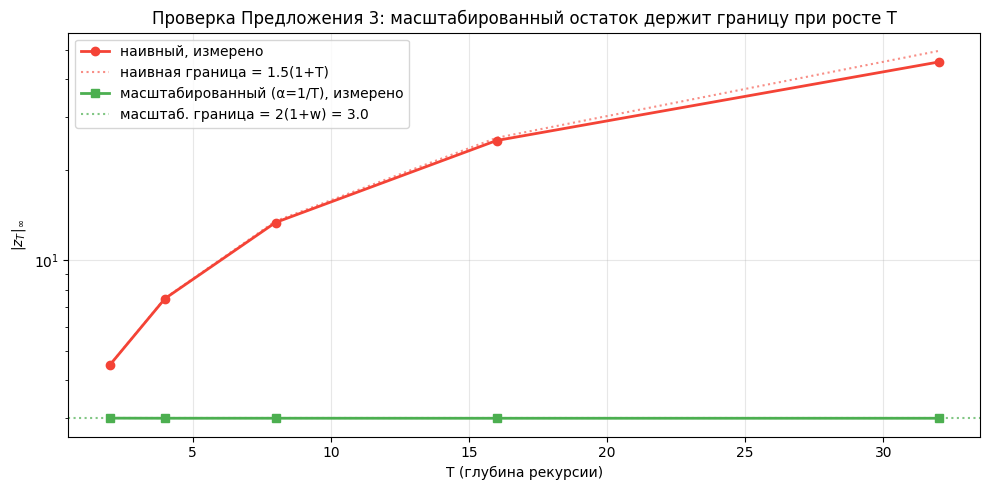

In [4]:
# === Визуализация: рост границы для наивного и масштабированного режимов ===

fig, ax = plt.subplots(figsize=(10, 5))
Ts = np.array(T_sweep)
naive = [r for r in results_p3 if r['mode'] == 'naive']
scaled = [r for r in results_p3 if r['mode'] == 'scaled']

ax.plot(Ts, [r['measured'] for r in naive], 'o-', color='#F44336',
        label='наивный, измерено', linewidth=2)
ax.plot(Ts, [r['bound'] for r in naive], ':', color='#F44336',
        label='наивная граница = 1.5(1+T)', alpha=0.6)
ax.plot(Ts, [r['measured'] for r in scaled], 's-', color='#4CAF50',
        label='масштабированный (α=1/T), измерено', linewidth=2)
ax.axhline(y=3.0, color='#4CAF50', linestyle=':', alpha=0.7,
           label='масштаб. граница = 2(1+w) = 3.0')

ax.set_xlabel('T (глубина рекурсии)')
ax.set_ylabel(r'$|z_T|_\infty$')
ax.set_title('Проверка Предложения 3: масштабированный остаток держит границу при росте T')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(PROTO_DIR / 'theory_proposition3_verification.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Свойство 4: форма распределения и пригодность к квантизации (предварительное)

Ограниченный диапазон — необходимое, но недостаточное условие пригодности к квантизации. На худшую ошибку квантизации влияет также форма распределения латента.

### Утверждение (эмпирическое)

Для равномерной $B$-битной квантизации $z \in [-R, R]$:
$$\mathbb{E}[\|z - Q(z)\|^2] \leq \frac{R^2 n}{(2^B - 1)^2} \cdot g(H(p_z))$$
где $H(p_z)$ — нормированная энтропия, $g(\cdot)$ — монотонно убывающая функция ($g(1) = 1/12$ для равномерного распределения; $g \to \infty$ для концентрированного).

### Эмпирические данные

Загружаем из последнего JSON эксперимента 02 (distribution analysis): три конфигурации показывают, что наивная рекурсия ломает форму распределения, а масштабированная её восстанавливает.

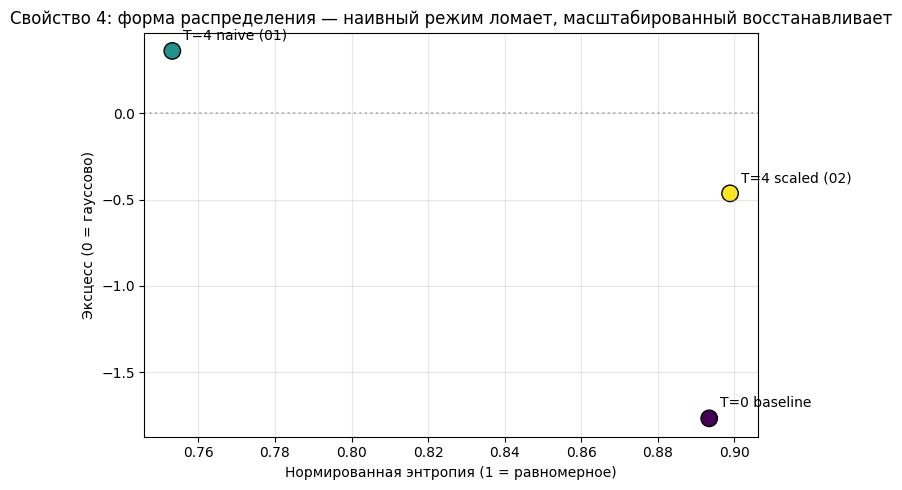

[{'config': 'T=0 baseline',
  'entropy': 0.893418317443335,
  'kurtosis': -1.767627394755795,
  'range': [-1.499996542930603, 1.499996542930603]},
 {'config': 'T=4 naive (01)',
  'entropy': 0.7531825360608723,
  'kurtosis': 0.3617884741429247,
  'range': [-7.043981552124023, 6.96855354309082]},
 {'config': 'T=4 scaled (02)',
  'entropy': 0.8988666621536864,
  'kurtosis': -0.4636736081395991,
  'range': [-2.9995970726013184, 2.9997034072875977]}]

In [5]:
# === Извлечение entropy и kurtosis из эксперимента 02 ===

stage1b = sorted(JSONS_DIR.glob('looped_chaos_stage1b_scaled_*.json'))
data_points = []
if stage1b:
    with open(stage1b[-1]) as f:
        j = json.load(f)
    if 'distribution_analysis' in j and j['distribution_analysis']:
        for name, stats in j['distribution_analysis'].items():
            data_points.append({
                'config': name,
                'entropy': stats.get('entropy_norm'),
                'kurtosis': stats.get('kurtosis'),
                'range': stats.get('range'),
            })

# === Визуализация entropy vs kurtosis ===

if len(data_points) >= 3:
    fig, ax = plt.subplots(figsize=(8, 5))
    ents = [d['entropy'] for d in data_points if d['entropy'] is not None]
    kurts = [d['kurtosis'] for d in data_points if d['kurtosis'] is not None]
    names = [d['config'] for d in data_points if d['entropy'] is not None]
    ax.scatter(ents, kurts, s=140, c=range(len(ents)), cmap='viridis', edgecolor='black')
    for i, n in enumerate(names):
        ax.annotate(n, (ents[i], kurts[i]), fontsize=10,
                    xytext=(8, 8), textcoords='offset points')
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Нормированная энтропия (1 = равномерное)')
    ax.set_ylabel('Эксцесс (0 = гауссово)')
    ax.set_title('Свойство 4: форма распределения — наивный режим ломает, масштабированный восстанавливает')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PROTO_DIR / 'theory_property4_shape.png', dpi=120, bbox_inches='tight')
    plt.show()

data_points

## 4. Кандидат в Теорему 5: устранение мёртвых экспертов в chaos-MoE

Условно на подтверждение V2 при N=3 в эксперименте 04.

### Постановка

Разреженный top-$k$ MoE: $f_e(x) = W_e^{(2)} \cdot \mathrm{chaos}(W_e^{(1)} x + b_e)$, маршрутизатор $r: \mathbb{R}^d \to \mathbb{R}^E$.

### Утверждение

Если маршрутизатор невырожден: $\forall e: \Pr_x[r_e(x) > \text{порог top-}k] > 0$, то
$$\Pr[\text{эксперт } e \text{ остаётся необученным}] = 0$$

### Скетч доказательства

По Теореме 2 chaos имеет ненулевой градиент почти всюду — выбранный эксперт получает нетривиальное обновление. По замечанию к Теореме 2, chaos нарушает монотонность ранжирования, что даёт ненулевую вероятность выбора даже для систематически слабых экспертов.

### Эмпирические данные

- V1 chaos-эксперты: 0/8 мёртвых (N=3 запуска, 100% воспроизводимость)
- V2 GELU-эксперты: 1/8 мёртвых (N=1, требуется N=3 в эксперименте 04)
- V3 chaos-маршрутизатор + chaos-эксперты: 0/8 мёртвых, энтропия = 0.86

## 5. Сохранение результатов

In [6]:
# === Сохранение всех verification результатов в JSON ===

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = {
    'experiment': 'theory_verification',
    'timestamp': ts,
    'theorem_1': thm1,
    'proposition_3': {
        'monte_carlo': results_p3,
        'all_pass': all(r['pass'] for r in results_p3),
    },
    'property_4': {'status': 'preliminary', 'data_points': data_points},
    'theorem_5_candidate': {'status': 'conditional on experiment 04 N=3 V2'},
}
out_file = JSONS_DIR / f'theory_verification_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
out_file

PosixPath('/Users/savenkovviktor/Documents/GitHub/k-sparse-chaos-autoencoder/jsons/theory_verification_20260427_135919.json')